# Sickle cell anemia classification using ML techniques on UCL dataset with XAI

### Import Libraries

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# ML & preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
import xgboost as xgb

# Deep learning
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.models import Model

### Extract VGG16 features

In [ ]:
# Dataset path and classes
dataset_path = "/kaggle/input/blood-films-4th/blood_films_4th"  # your dataset folder
classes = ["pos", "neg"]

# Load VGG16 base model
base_model = VGG16(weights='imagenet', include_top=False)
feature_model = Model(inputs=base_model.input, outputs=base_model.output)

features = []
labels = []

for cls in classes:
    folder = os.path.join(dataset_path, cls)
    for file in tqdm(os.listdir(folder), desc=f"Processing {cls}"):
        img_path = os.path.join(folder, file)
        img = cv2.imread(img_path)
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img, (224, 224))
        img_input = np.expand_dims(img_resized, axis=0)
        img_input = preprocess_input(img_input)

        # Extract features
        feat = feature_model.predict(img_input)
        features.append(feat.flatten())
        labels.append(cls)

features = np.array(features)
labels = np.array(labels)

# Save for later use
np.save("features.npy", features)
np.save("labels.npy", labels)

print("Features shape:", features.shape)
print("Labels shape:", labels.shape)

### Prepare data for ML

In [4]:
# Load features and labels (if starting fresh)
# features = np.load("features.npy")
# labels = np.load("labels.npy")

# Encode labels
le = LabelEncoder()
y = le.fit_transform(labels)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    features, y, test_size=0.2, random_state=42, stratify=y
)
print("Train/Test shapes:", X_train.shape, X_test.shape)

Train/Test shapes: (1588, 25088) (398, 25088)


### Occlusion Sensitivity

In [5]:
def occlusion_sensitivity(img_path, model, base_model, patch_size=30):
    """
    Compute occlusion sensitivity for any ML model trained on VGG16 features.
    Args:
        img_path: path to the test image
        model: trained ML model (e.g., SVM, RandomForest, etc.)
        base_model: pretrained CNN feature extractor (e.g., VGG16 without top)
        patch_size: size of occluded patch
    """
    from tensorflow.keras.preprocessing.image import load_img, img_to_array
    from tensorflow.keras.applications.vgg16 import preprocess_input
    import numpy as np
    import cv2

    # Load and preprocess image
    img = load_img(img_path, target_size=(224, 224))
    img_array = img_to_array(img)
    h, w, _ = img_array.shape

    # Extract VGG16 features for the base image
    feat_base = base_model.predict(preprocess_input(np.expand_dims(img_array, axis=0)))
    feat_base = feat_base.flatten().reshape(1, -1)

    # Base prediction and class confidence
    base_pred = model.predict_proba(feat_base)[0]
    base_class = np.argmax(base_pred)
    base_prob = base_pred[base_class]

    # Initialize heatmap
    heatmap = np.zeros((h, w))

    # Slide occlusion window
    for y in range(0, h, patch_size):
        for x in range(0, w, patch_size):
            occluded = img_array.copy()
            occluded[y:y+patch_size, x:x+patch_size, :] = 0  # black patch
            feat_occ = base_model.predict(preprocess_input(np.expand_dims(occluded, axis=0)))
            feat_occ = feat_occ.flatten().reshape(1, -1)

            pred_occ = model.predict_proba(feat_occ)[0]
            prob_occ = pred_occ[base_class]
            heatmap[y:y+patch_size, x:x+patch_size] = base_prob - prob_occ  # drop in confidence

    # Normalize heatmap
    heatmap = np.maximum(heatmap, 0)
    if np.max(heatmap) > 0:
        heatmap /= np.max(heatmap)

    return img_array, heatmap


# -----------------------------
# Visualization helper
# -----------------------------
import matplotlib.pyplot as plt
import cv2
import numpy as np

def show_overlay(img, heatmap):
    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(cv2.cvtColor(np.uint8(img), cv2.COLOR_RGB2BGR), 0.6, heatmap_color, 0.4, 0)
    
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(np.uint8(img))
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    plt.title("Occlusion Sensitivity")
    plt.axis("off")

    plt.show()

### Input Image

In [6]:
test_img = "/kaggle/input/blood-films-4th/blood_films_4th/pos/1022.png"  # path to one test image

### Decision Tree

Decision Tree Accuracy: 0.7814070351758794
              precision    recall  f1-score   support

           0       0.63      0.58      0.60       114
           1       0.84      0.86      0.85       284

    accuracy                           0.78       398
   macro avg       0.73      0.72      0.73       398
weighted avg       0.78      0.78      0.78       398

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━

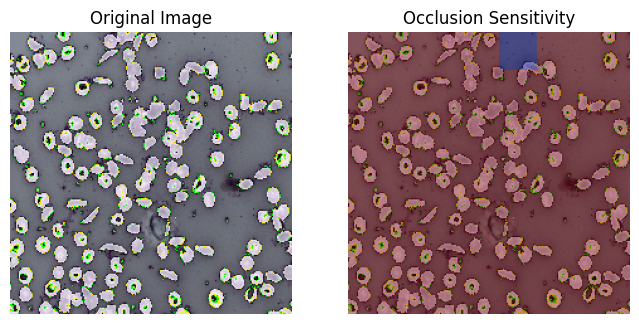

In [7]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

img, heatmap = occlusion_sensitivity(test_img, dt, base_model)
show_overlay(img, heatmap)

### Logistic Regression

Logistic Regression Accuracy: 0.8944723618090452
              precision    recall  f1-score   support

           0       0.88      0.73      0.80       114
           1       0.90      0.96      0.93       284

    accuracy                           0.89       398
   macro avg       0.89      0.84      0.86       398
weighted avg       0.89      0.89      0.89       398

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━

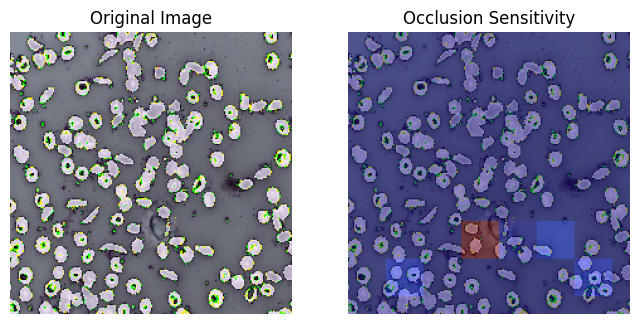

In [8]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

img, heatmap = occlusion_sensitivity(test_img, lr, base_model)
show_overlay(img, heatmap)

### LightGBM

[LightGBM] [Info] Number of positive: 1134, number of negative: 454
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.310161 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 978635
[LightGBM] [Info] Number of data points in the train set: 1588, number of used features: 10236
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.714106 -> initscore=0.915409
[LightGBM] [Info] Start training from score 0.915409
LightGBM Accuracy: 0.914572864321608
              precision    recall  f1-score   support

           0       0.94      0.75      0.83       114
           1       0.91      0.98      0.94       284

    accuracy                           0.91       398
   macro avg       0.93      0.86      0.89       398
weighted avg       0.92      0.91      0.91       398

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 4

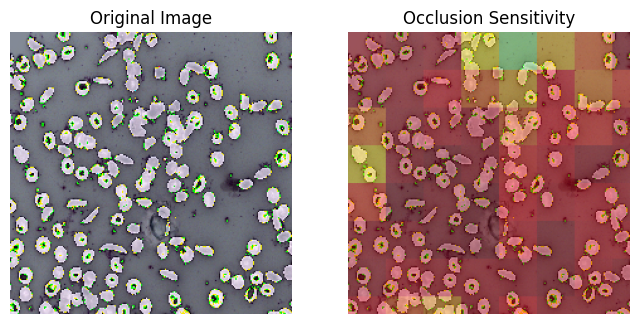

In [9]:
lgbm = lgb.LGBMClassifier()
lgbm.fit(X_train, y_train)
y_pred = lgbm.predict(X_test)
print("LightGBM Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

img, heatmap = occlusion_sensitivity(test_img, lgbm, base_model)
show_overlay(img, heatmap)

### SVM

SVM Accuracy: 0.9271356783919598
              precision    recall  f1-score   support

           0       0.97      0.77      0.86       114
           1       0.92      0.99      0.95       284

    accuracy                           0.93       398
   macro avg       0.94      0.88      0.90       398
weighted avg       0.93      0.93      0.92       398

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms

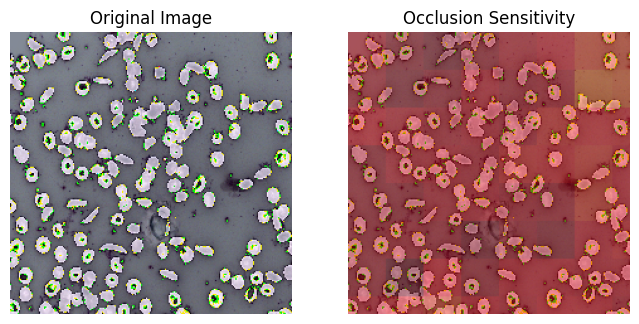

In [10]:
svm = SVC(probability=True)
svm.fit(X_train, y_train)
y_pred = svm.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

img, heatmap = occlusion_sensitivity(test_img, svm, base_model)
show_overlay(img, heatmap)

### Naive Bayes

Naive Bayes Accuracy: 0.7638190954773869
              precision    recall  f1-score   support

           0       0.72      0.29      0.41       114
           1       0.77      0.95      0.85       284

    accuracy                           0.76       398
   macro avg       0.74      0.62      0.63       398
weighted avg       0.75      0.76      0.73       398

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━

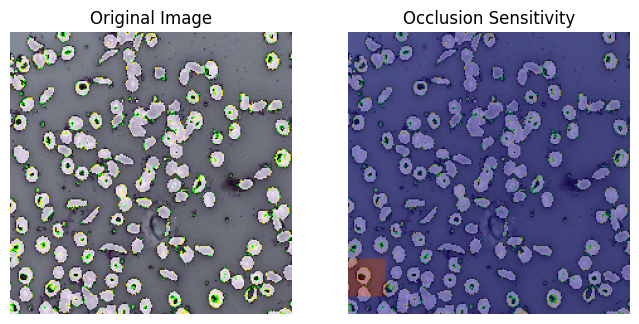

In [11]:
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred = nb.predict(X_test)
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

img, heatmap = occlusion_sensitivity(test_img, nb, base_model, patch_size=30)
show_overlay(img, heatmap)

### Random Forest

Random Forest Accuracy: 0.8668341708542714
              precision    recall  f1-score   support

           0       0.92      0.59      0.72       114
           1       0.86      0.98      0.91       284

    accuracy                           0.87       398
   macro avg       0.89      0.78      0.81       398
weighted avg       0.87      0.87      0.86       398

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━

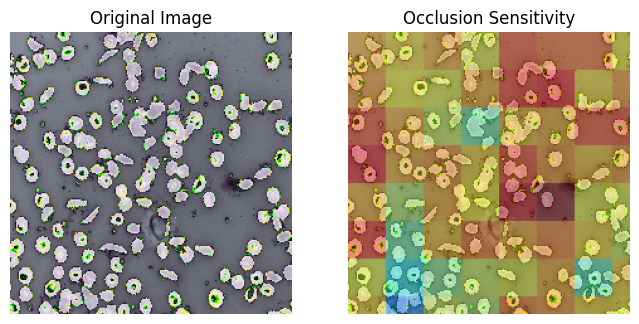

In [12]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

img, heatmap = occlusion_sensitivity(test_img, rf, base_model)
show_overlay(img, heatmap)

### XGBoost

XGBoost Accuracy: 0.8969849246231156
              precision    recall  f1-score   support

           0       0.91      0.71      0.80       114
           1       0.89      0.97      0.93       284

    accuracy                           0.90       398
   macro avg       0.90      0.84      0.86       398
weighted avg       0.90      0.90      0.89       398

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

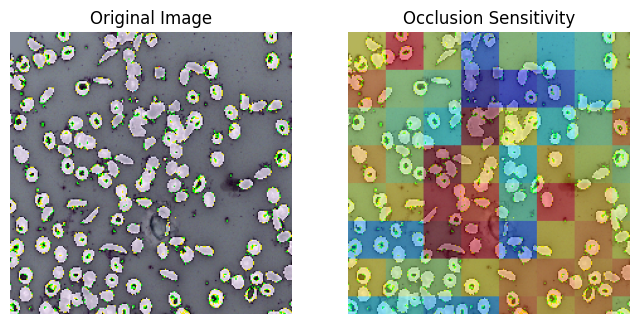

In [13]:
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

img, heatmap = occlusion_sensitivity(test_img, xgb_model, base_model, patch_size=30)
show_overlay(img, heatmap)

### KNN

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
print("KNN Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

img, heatmap = occlusion_sensitivity(test_img, knn, base_model)
show_overlay(img, heatmap)